In [1]:
include("dependencies.jl")
include("system_params.jl")
include("functions.jl")

f (generic function with 1 method)

In [2]:
total_qubits

5

In [3]:
# N_trajectories = 1

# basis = NLevelBasis(2)
# k = transition(basis,2,2)
# n_a = full_operator(k,total_qubits, [1])
# n_c = full_operator(k, total_qubits, [3])
# n_ac = full_operator(k, total_qubits, [1,3])


# ψ0 = initialize_system()
# println("The system has been initialized.")
# # p1 = qubit_parameters(Ω, γ_Decay, γ_dephase, V_nn, δ)
# tspan = [0.0:1:T_optimal;]

# full_basis = CompositeBasis([NLevelBasis(2) for _ in 1:total_qubits]...)


# population_a = zeros(length(tspan))
# population_c = zeros(length(tspan))
# population_ac = zeros(length(tspan))

# println("Starting the simulation...")
# flush(stdout)
# for i in 1:N_trajectories
#     ψ0_ket = Ket(full_basis, ComplexF64.(ψ0)) 
#     @time tout, ψt = timeevolution.mcwf_dynamic(tspan,ψ0_ket,f;alg=Rodas3(autodiff=false),maxiters=1e7);
#     println("Trajectory $i")
#     population_a[i] = real(expect(n_a, ψt))
#     population_c[i] =  real(expect(n_c, ψt))
#     population_ac[i] = real(expect(n_ac, ψt))
# end

# population_a ./= N_trajectories
# population_c ./= N_trajectories
# population_ac ./= N_trajectories


# println("Simulation complete. Saving data...")

In [63]:
ρ_master[end]

Operator(dim=32x32)
  basis: [NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2)]
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
    ⋮                             ⋱                ⋮       
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0

In [2]:
ψ0 = initialize_system()
basis = CompositeBasis([NLevelBasis(2) for _ in 1:total_qubits]...)
ψ0_ket = Ket(basis, ComplexF64.(ψ0));

In [3]:
tout, ψt = timeevolution.mcwf_dynamic(tspan,ψ0_ket,f,maxiters=1e9);

In [20]:
@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/5atom_master_γ_decay=0.001.jld2"
ρ_master = ρt;

In [6]:
m = length(tspan)
l = 1
ρ_avg = Vector{Matrix}(undef,m)
for j in 1:m
    ρ_sum = zero(ψt[j].data * ψt[j].data')  # Initialize sum with a zero matrix of the same type
    for i in 1:l
        ρ_sum .+= (ψt[j].data * ψt[j].data')
    end
    ρ_avg[j] = ρ_sum;
end

In [28]:
T = []
for i in 1:length(tspan)
    push!(T, 0.5 * real(tr(abs.((ρ_master[i].data .- ρ_avg[i])))))
end

T[T .<= 0] .= 1e-5;

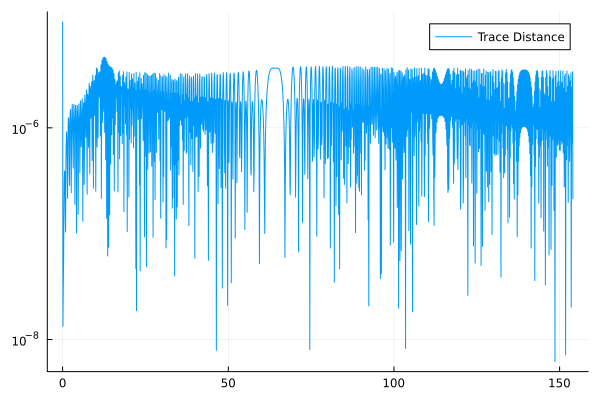

In [29]:
plot(tspan, T, yscale=:log10, label="Trace Distance")

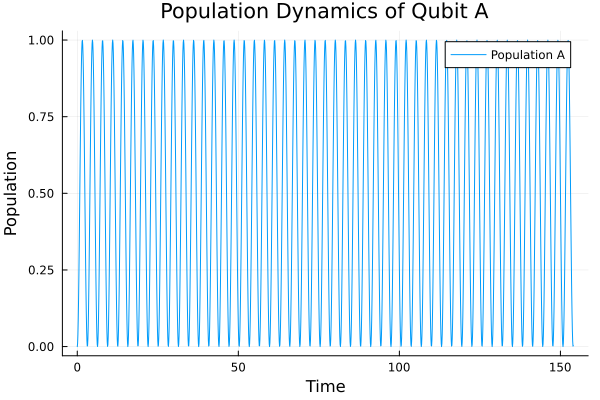

In [18]:
using Plots
plot(tspan, pop_c, label="Population A", xlabel="Time", ylabel="Population", title="Population Dynamics of Qubit A")
# plot!(tout, pop_c, label="Population C")